In [25]:
import numpy as np
import random
import pandas as pd
from scipy.stats import norm
import torch
import torch.nn as nn
import normflows as nf
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.stats import norm
from tqdm import tqdm
np.random.seed(0)

I = 3
sigma = 1
tau = 2
gamma = -5
A = 0.5
thetas = np.random.normal(gamma ,tau, I)
Y = np.random.normal(thetas,sigma)
print("Theta Values: ", np.round(thetas,3), ", Y values: ", np.round(Y,3))

Theta Values:  [-1.472 -4.2   -3.043] , Y values:  [ 0.769 -2.332 -4.02 ]


In [19]:
# :::::::::::::::::::::::::::::::::::
# Function generate CBC samples
# :::::::::::::::::::::::::::::::::::
cbc_mean = Y*(A**2)/(A**2+sigma**2)
cbc_sd = np.sqrt((A**2*sigma**2)/(A**2+sigma**2))
# generates theta samples from the CBC distribution
def CBC_sample_generator(num_samples = 1):
    samples = np.random.normal(loc=cbc_mean, scale=cbc_sd, size=(num_samples, I))
    column_names = [f"Group{i+1}" for i in range(I)]
    return pd.DataFrame(samples, columns=column_names)
# :::::::::::::::::::::::::::::::::::
# True CBC pdf values
# :::::::::::::::::::::::::::::::::::
def CBC_density(theta):
    """ theta should be a vector of size I or a dataframe with I columns """
    return norm.pdf(theta,loc = cbc_mean, scale = cbc_sd).tolist()

## Stage 1: Finding the density of the sampler using CBC samples (Forward KL)

100%|██████████| 2000/2000 [00:03<00:00, 514.06it/s]


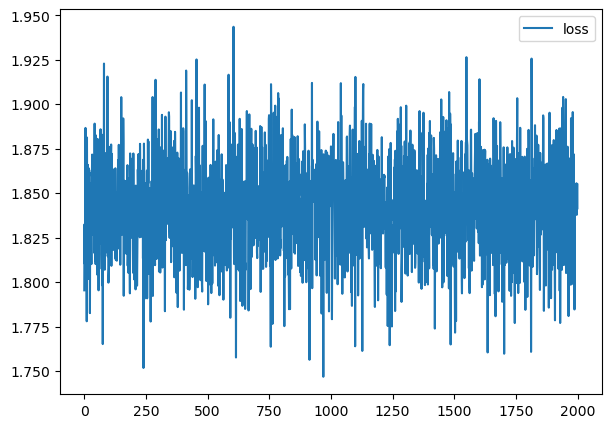

In [20]:
K = 2
torch.manual_seed(0)

latent_size = I
b = torch.Tensor([1 if i % 2 == 0 else 0 for i in range(latent_size)])
flows = []
for i in range(K):
    s = nf.nets.MLP([latent_size, 2 * latent_size, latent_size], init_zeros=True)
    t = nf.nets.MLP([latent_size, 2 * latent_size, latent_size], init_zeros=True)
    if i % 2 == 0:
        flows += [nf.flows.MaskedAffineFlow(b, t, s)]
    else:
        flows += [nf.flows.MaskedAffineFlow(1 - b, t, s)]
    flows += [nf.flows.ActNorm(latent_size)]

# Base Distribution - Standard Normal
q0 = nf.distributions.DiagGaussian(I)

# Construct flow model
# Forward kl so we don't specify p = target
nfm = nf.NormalizingFlow(q0=q0, flows=flows)
device = torch.device('cpu')
nfm = nfm.to(device)
nfm = nfm.float()

# Train model
max_iter = 2000
num_samples = 2000

loss_hist = np.array([])
optimizer = torch.optim.Adam(nfm.parameters(), lr=1e-4, weight_decay=1e-6)

for it in tqdm(range(max_iter)):
    optimizer.zero_grad()
    loss = nfm.forward_kld(torch.tensor(CBC_sample_generator(num_samples).values, dtype=torch.float32))
    
    if ~(torch.isnan(loss) | torch.isinf(loss)):
        loss.backward()
        optimizer.step()
    
    loss_hist = np.append(loss_hist, loss.to(device).data.numpy())

plt.figure(figsize=(6, 4))
plt.plot(loss_hist, label='loss')
plt.legend()
plt.show()

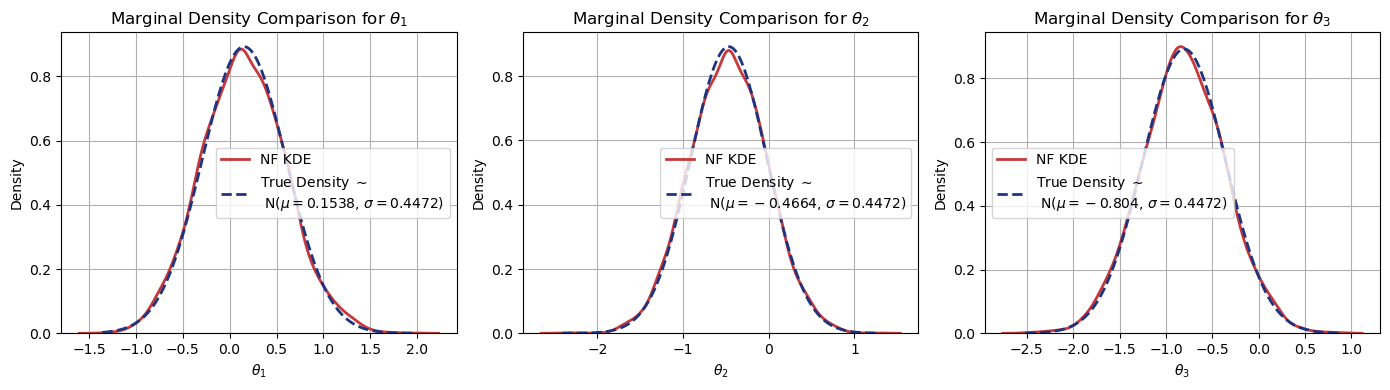

In [21]:
random.seed(0)
torch.manual_seed(0)

z, _ = nfm.sample(5000)
z = z.detach().cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes = axes.flatten()

for i in range(I):
    ax = axes[i]
    
    sns.kdeplot(z[:, i], color='#C7383A', linewidth=2, ax=ax, label='NF KDE')
    
    x_vals = np.linspace(z[:, i].min(), z[:, i].max(), 200)
    normal_density = norm.pdf(x_vals, loc=cbc_mean[i], scale=cbc_sd)
    ax.plot(x_vals, normal_density, color='#1F3480', linestyle='dashed', linewidth=2,
            label=f'True Density $\\sim$ \n N($\\mu={np.round(cbc_mean[i],4)}$, $\\sigma={np.round(cbc_sd,4)}$)')
    
    ax.set_xlabel(rf'$\theta_{i+1}$')
    ax.set_ylabel("Density")
    ax.set_title(rf"Marginal Density Comparison for $\theta_{i+1}$")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()


In [22]:
# :::::::::::::::::::::::::::::::::::
# Summary Statistics - Mean and Standard Deviation Comparisons
# :::::::::::::::::::::::::::::::::::
for i in range(I):
    print(f"Theta {i+1} \n ----------------------------")
    print(f"SD of the NF Generated Samples (Theta {i+1}): {np.round(np.std(z[:,i]),4)} vs Sigma = ",cbc_sd)
    print(f"Mean of NF Generated Samples (Theta = {i+1}) {np.round(np.mean(z[:,i]),4)} vs True Y = " ,cbc_mean[i])
    print("----------------------------")

Theta 1 
 ----------------------------
SD of the NF Generated Samples (Theta 1): 0.4503999948501587 vs Sigma =  0.4472135954999579
Mean of NF Generated Samples (Theta = 1) 0.15150000154972076 vs True Y =  0.15379957822735718
----------------------------
Theta 2 
 ----------------------------
SD of the NF Generated Samples (Theta 2): 0.44920000433921814 vs Sigma =  0.4472135954999579
Mean of NF Generated Samples (Theta = 2) -0.4722000062465668 vs True Y =  -0.46642551862311726
----------------------------
Theta 3 
 ----------------------------
SD of the NF Generated Samples (Theta 3): 0.44940000772476196 vs Sigma =  0.4472135954999579
Mean of NF Generated Samples (Theta = 3) -0.8109999895095825 vs True Y =  -0.8039603823329864
----------------------------


In [23]:
# :::::::::::::::::::::::::::::::::::
# KS Test Results
# :::::::::::::::::::::::::::::::::::
from scipy import stats
np.random.seed(0)
random.seed(0)
torch.manual_seed(0)
true_samples = CBC_sample_generator(2000)
z, log_q = nfm.sample(2000)
z = z.detach().cpu().numpy() 
for i in range(I):
    nf_sample1 = z[:,i]
    true_sample2 = true_samples.iloc[:,i]
    print(f"KS Test: Theta {i+1} \n ---------------------")
    print(stats.kstest(nf_sample1, true_sample2))
    print("---------------------")

KS Test: Theta 1 
 ---------------------
KstestResult(statistic=np.float64(0.012), pvalue=np.float64(0.9987511305163623), statistic_location=np.float64(0.33326607942581177), statistic_sign=np.int8(1))
---------------------
KS Test: Theta 2 
 ---------------------
KstestResult(statistic=np.float64(0.015), pvalue=np.float64(0.9780895655250116), statistic_location=np.float64(-0.05730852484703064), statistic_sign=np.int8(1))
---------------------
KS Test: Theta 3 
 ---------------------
KstestResult(statistic=np.float64(0.0195), pvalue=np.float64(0.8416360266077476), statistic_location=np.float64(-0.6654476769734609), statistic_sign=np.int8(-1))
---------------------


## Step 2: Evaluating the posterior distribution using the output from step 1 (Reverse KLD)
Target Distribution
$$P(\theta ,\gamma \mid Y) \propto P(\gamma) \prod_{i=1}^I P(\theta_i\mid \gamma,\tau^2) P(Y_i\mid\theta_i)$$


$$\theta_i \mid Y \sim N(\mu_i, \frac{\sigma^2\tau^2}{\tau^2 + \sigma^2} + \frac{\sigma^4}{J(\sigma^2+ \tau^2)})$$
where $\mu_i = \frac{\sigma^2 \bar{Y} + \tau^2 Y_i}{\sigma^2 + \tau^2}$
Similarly:

$$\gamma \mid Y \sim N(\bar{Y}, \frac{\sigma^2 + \tau^2}{J})$$

100%|██████████| 5000/5000 [00:19<00:00, 251.66it/s]


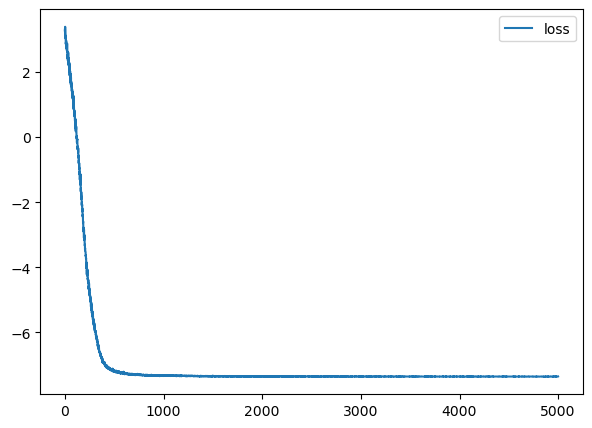

In [26]:
torch.manual_seed(0)

# Fixing the parameters of Stage 1 model
nfm = nfm.to(device).float().eval()
for p in nfm.parameters():
        p.requires_grad_(False)

# Flow structure
K = 3
latent_size = I + 1
b = torch.Tensor([1 if i % 2 == 0 else 0 for i in range(latent_size)])
flows = []
for i in range(K):
    s = nf.nets.MLP([latent_size, 3 * latent_size, latent_size], init_zeros=True)
    t = nf.nets.MLP([latent_size, 3 * latent_size, latent_size], init_zeros=True)
    if i % 2 == 0:
        flows += [nf.flows.MaskedAffineFlow(b, t, s)]
    else:
        flows += [nf.flows.MaskedAffineFlow(1 - b, t, s)]
flows += [nf.flows.ActNorm(latent_size)]

# Target distribution: Posterior density of all parameters
class MyCustomTarget(nn.Module):
    def __init__(self):
        super().__init__()

    def log_prob(self, t):
        theta_value = t[:, :I] 
        gamma_value = t[:, I].unsqueeze(-1) 
        
        log_p_nfm = nfm.log_prob(theta_value)
        log_p_normal = torch.distributions.Normal(gamma_value, tau).log_prob(theta_value).sum(dim=-1)
        log_p_cbc = torch.distributions.Normal(0, A).log_prob(theta_value).sum(dim=-1)
        return log_p_nfm + log_p_normal - log_p_cbc


q0_new = nf.distributions.DiagGaussian(I+1)
my_target = MyCustomTarget()
nfm2 = nf.NormalizingFlow(q0=q0_new, flows=flows, p=my_target)
nfm2 = nfm2.to(device)
nfm2 = nfm2.float()

with torch.no_grad():
    _ = nfm2.sample(20000)
    
# Training Setup
max_iter = 5000
num_samples0 = 1000

loss_hist = np.array([])
optimizer = torch.optim.Adam(nfm2.parameters(), lr=5e-4, weight_decay=1e-6)

for it in tqdm(range(max_iter)):
    optimizer.zero_grad()
    loss = nfm2.reverse_kld(num_samples = num_samples)
    
    if torch.isnan(loss) or torch.isinf(loss):
        print(f"⚠️ NaN or Inf detected in loss at iteration {it}")
        continue 

    if ~(torch.isnan(loss) | torch.isinf(loss)):
        loss.backward()
        optimizer.step()

    loss_hist = np.append(loss_hist, loss.to('cpu').data.numpy())
    
plt.figure(figsize=(6, 4))
plt.plot(loss_hist, label='loss')
plt.legend()
plt.show()


In [29]:
# :::::::::::::::::::::::::::::::::::
# Saving the output: a dataset of model generated samples
# :::::::::::::::::::::::::::::::::::

random.seed(123)
torch.manual_seed(123)
np.random.seed(123)

nfm2.eval()
z, log_q = nfm2.sample(5000)
prob = torch.exp(log_q)
prob[torch.isnan(prob)] = 0

z = z.detach().cpu().numpy() 
df_z = pd.DataFrame(z)
df_z.columns = [f"dim_{i+1}" for i in range(z.shape[1])]  
df_z.to_csv("nf_samples.csv", index=False)

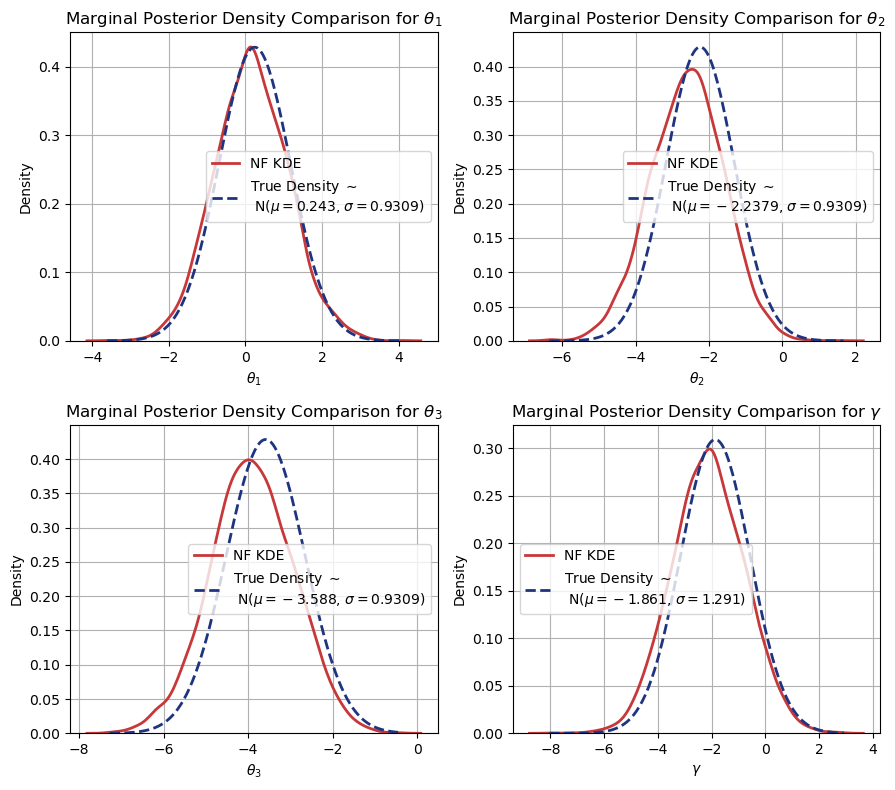

In [32]:
random.seed(0)
torch.manual_seed(0)

z, _ = nfm2.sample(5000)
z = z.detach().cpu().numpy()

fig, axes = plt.subplots(2, 2, figsize=(9, 8))
axes = axes.flatten()

var_posterior = ((sigma**2) * (tau**2))/(sigma**2+tau**2) + sigma**4/(I*(sigma**2+tau**2))
sd_posterior = np.sqrt(var_posterior)

mean_posterior = [((sigma**2)*np.mean(Y)+ (tau**2)*Y[i])/(sigma**2+tau**2) for i in range(I)]

# ---- Theta plots ----
for i in range(I):
    ax = axes[i]
    
    sns.kdeplot(z[:, i], color='#C7383A', linewidth=2, ax=ax, label='NF KDE')
    
    x_vals = np.linspace(z[:, i].min(), z[:, i].max(), 200)
    normal_density = norm.pdf(x_vals, loc=mean_posterior[i], scale=sd_posterior)
    
    ax.plot(x_vals, normal_density, color='#1F3480', linestyle='dashed', linewidth=2,
            label=f'True Density $\\sim$ \n N($\\mu={np.round(mean_posterior[i],4)}$, $\\sigma={np.round(sd_posterior,4)}$)')
    
    ax.set_xlabel(rf'$\theta_{i+1}$')
    ax.set_ylabel("Density")
    ax.set_title(rf"Marginal Posterior Density Comparison for $\theta_{i+1}$")
    ax.legend()
    ax.grid(True)

gamma_mean = np.mean(Y)
gamma_sd = np.sqrt((sigma**2 + tau**2) / I)

ax = axes[I]

sns.kdeplot(z[:, I], color='#C7383A', linewidth=2, ax=ax, label='NF KDE')

x_vals = np.linspace(z[:, I].min(), z[:, I].max(), 200)
normal_density = norm.pdf(x_vals, loc=gamma_mean, scale=gamma_sd)

ax.plot(x_vals, normal_density, color='#1F3480', linestyle='dashed', linewidth=2,
        label=f'True Density $\\sim$ \n N($\\mu={np.round(gamma_mean,4)}$, $\\sigma={np.round(gamma_sd,4)}$)')

ax.set_xlabel(r'$\gamma$')
ax.set_ylabel("Density")
ax.set_title(r"Marginal Posterior Density Comparison for $\gamma$")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()


In [33]:
# :::::::::::::::::::::::::::::::::::
# KS Test Results
# :::::::::::::::::::::::::::::::::::
for i in range(I):
    print(f"Theta {i+1} \n ----------------------------")
    print(f"SD of the NF Generated Samples: {np.round(np.std(z[:,i]),4)} vs SD = {sd_posterior}, | Error: {np.round(sd_posterior - np.std(z[:,i]),4)}")
    print(f"Mean of the NF Generated Samples: {np.round(np.mean(z[:,i]),4)} vs True Mean = {mean_posterior[i]}, | Error: {np.round(mean_posterior[i] - np.mean(z[:,i]),4)}")
    print("----------------------------")
print(f"Gamma \n ----------------------------")
print(f"SD of the NF Generated Samples: {np.round(np.std(z[:,I]),4)} vs SD = {gamma_sd}, | Error: {np.round(gamma_sd-np.std(z[:,I]),4)}")
print(f"Mean of the NF Generated Samples: {np.round(np.mean(z[:,I]),4)} vs True Mean = {gamma_mean}, | Error: {np.round(gamma_mean-np.mean(z[:,I]),4)}")
print("----------------------------")

Theta 1 
 ----------------------------
SD of the NF Generated Samples: 0.9591000080108643 vs SD = 0.9309493362512627, | Error: -0.0281
Mean of the NF Generated Samples: 0.16930000483989716 vs True Mean = 0.2430028719998465, | Error: 0.0737
----------------------------
Theta 2 
 ----------------------------
SD of the NF Generated Samples: 0.995199978351593 vs SD = 0.9309493362512627, | Error: -0.0643
Mean of the NF Generated Samples: -2.587599992752075 vs True Mean = -2.237897515402051, | Error: 0.3497
----------------------------
Theta 3 
 ----------------------------
SD of the NF Generated Samples: 0.9843000173568726 vs SD = 0.9309493362512627, | Error: -0.0533
Mean of the NF Generated Samples: -3.904599905014038 vs True Mean = -3.588036970241528, | Error: 0.3166
----------------------------
Gamma 
 ----------------------------
SD of the NF Generated Samples: 1.3483999967575073 vs SD = 1.2909944487358056, | Error: -0.0574
Mean of the NF Generated Samples: -2.1092000007629395 vs True M

## Two Stage Fully Bayesian Algorithm


In [34]:
np.random.seed(0)
random.seed(0)
# Stage 1: Generate CBC samples
T = 30000 # Number of samples per theta
theta_cbc_samples = CBC_sample_generator(T).to_numpy().T
theta_ts = np.zeros((I, T)) 
gamma_ts = np.zeros(T)
for i in range(I):
    theta_ts[i, 0] = random.choice(theta_cbc_samples[i])

# MCMC Sampling Process
for t in range(1, T):
    # Stage 2a: Sample new gamma from Normal(Mean of theta_ts[t-1], tau^2 / I)
    gamma_ts[t] = np.random.normal(loc=np.mean(theta_ts[:, t-1]), scale=tau / np.sqrt(I))

    # Stage 2c: Update each theta_i using MH within Gibbs
    for i in range(I):
        # Propose new theta_i sample from the CBC samples
        theta_prop = random.choice(theta_cbc_samples[i])
        # Compute Metropolis-Hastings acceptance ratio
        num = norm.pdf(theta_prop, gamma_ts[t], tau) / norm.pdf(theta_prop, 0, A)
        den = norm.pdf(theta_ts[i, t-1], gamma_ts[t], tau) / norm.pdf(theta_ts[i, t-1], 0, A)
        R_i = num / den
        # Accept/reject step
        if np.random.uniform(0, 1) < min(1, R_i):
            theta_ts[i, t] = theta_prop
        else:
            theta_ts[i, t] = theta_ts[i, t-1]

# Store the results
two_stage_FB_results = pd.DataFrame(theta_ts.T, columns=[f"theta_{i+1}" for i in range(I)])
two_stage_FB_results["gamma"] = gamma_ts 
two_stage_FB_results.to_csv("two_stage_FB_simple_hierarchical_model.csv", index=False)

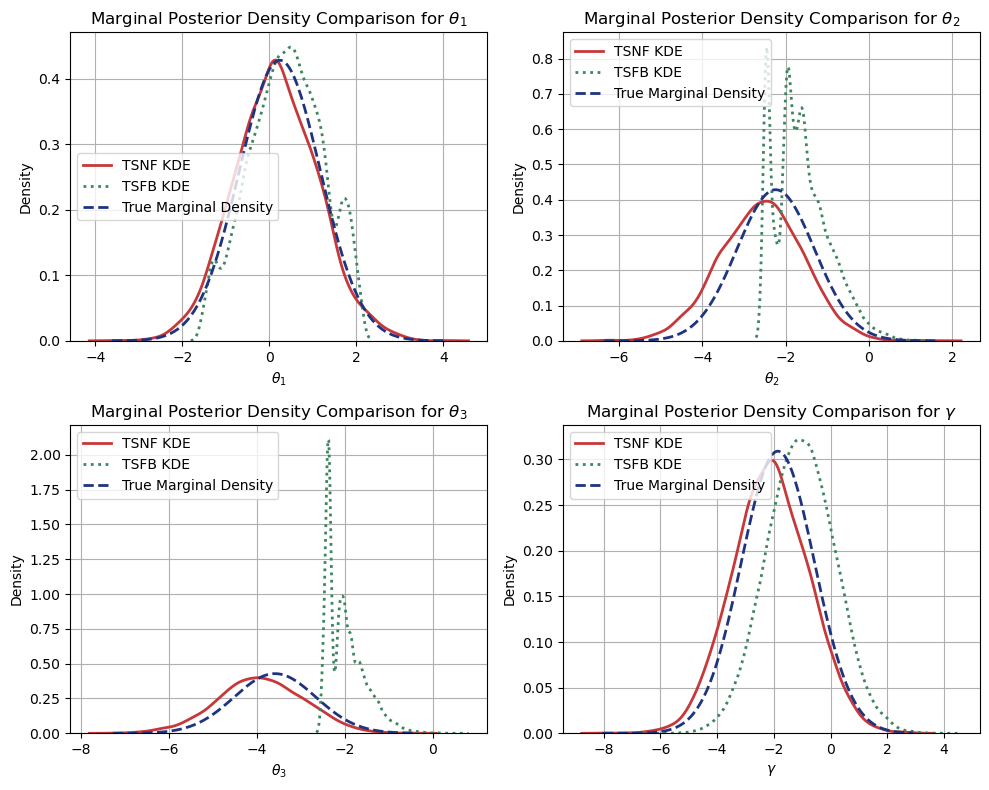

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i in range(I):
    ax = axes[i]

    sns.kdeplot(z[:, i], color='#C7383A', linewidth=2, ax=ax,
                label='TSNF KDE')
    sns.kdeplot(two_stage_FB_results.iloc[:, i], color='#3C855F',
                linestyle='dotted', linewidth=2, ax=ax,
                label='TSFB KDE')

    x_vals = np.linspace(z[:, i].min(), z[:, i].max(), 200)
    normal_density = norm.pdf(x_vals, loc=mean_posterior[i], scale=sd_posterior)
    ax.plot(x_vals, normal_density, color='#1F3480', linestyle='dashed', linewidth=2,
            label='True Marginal Density')

    ax.set_xlabel(rf'$\theta_{i+1}$')
    ax.set_ylabel("Density")
    ax.set_title(rf"Marginal Posterior Density Comparison for $\theta_{i+1}$")
    ax.legend()
    ax.grid(True)

ax = axes[I]

sns.kdeplot(z[:, I], color='#C7383A', linewidth=2, ax=ax,
            label='TSNF KDE')
sns.kdeplot(two_stage_FB_results.iloc[:, I], color='#3C855F',
            linestyle='dotted', linewidth=2, ax=ax,
            label='TSFB KDE')

x_vals = np.linspace(z[:, I].min(), z[:, I].max(), 200)
normal_density = norm.pdf(x_vals, loc=gamma_mean, scale=gamma_sd)
ax.plot(x_vals, normal_density, color='#1F3480', linestyle='dashed', linewidth=2,
        label='True Marginal Density')

ax.set_xlabel(r'$\gamma$')
ax.set_ylabel("Density")
ax.set_title(r"Marginal Posterior Density Comparison for $\gamma$")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()


In [38]:
# :::::::::::::::::::::::::::::::::::
# Error in marginal posterior parameter estimation
# :::::::::::::::::::::::::::::::::::
for i in range(I):
    print(f"Theta {i+1} \n ----------------------------")
    print(f"SD Error: TSNF = {np.round(np.std(z[:,i])- sd_posterior,4)} vs. TSFB = {np.round(np.std(two_stage_FB_results.iloc[:,i]) - sd_posterior,4)}")
    print(f"Mean Error: TSNF = {np.round(np.mean(z[:,i])- mean_posterior[i],4)} vs. TSFB = {np.round(np.mean(two_stage_FB_results.iloc[:,i])-mean_posterior[i],4)}")
    print("----------------------------")

print(f"Gamma \n ----------------------------")
print(f"SD Error: TSNF = {np.round(np.std(z[:,I])- gamma_sd,4)} vs. TSFB = {np.round(np.std(two_stage_FB_results.iloc[:,I]) - gamma_sd,4)}")
print(f"Mean Error: TSNF = {np.round(np.mean(z[:,I])- gamma_mean,4)} vs. TSFB = {np.round(np.mean(two_stage_FB_results.iloc[:,I])-gamma_mean,4)}")
  

Theta 1 
 ----------------------------
SD Error: TSNF = 0.0281 vs. TSFB = -0.0917
Mean Error: TSNF = -0.0737 vs. TSFB = 0.1496
----------------------------
Theta 2 
 ----------------------------
SD Error: TSNF = 0.0643 vs. TSFB = -0.28
Mean Error: TSNF = -0.3497 vs. TSFB = 0.6257
----------------------------
Theta 3 
 ----------------------------
SD Error: TSNF = 0.0533 vs. TSFB = -0.4938
Mean Error: TSNF = -0.3166 vs. TSFB = 1.6077
----------------------------
Gamma 
 ----------------------------
SD Error: TSNF = 0.0574 vs. TSFB = -0.0788
Mean Error: TSNF = -0.2483 vs. TSFB = 0.8038


## Correlations

In [39]:
covariance_NF = np.cov(z[:,:I], rowvar=False)
covariance_FB = np.cov(two_stage_FB_results.iloc[:,:I], rowvar=False)

theta_cov = sigma**4/(I*(sigma**2+tau**2))
true_cov_matrix = np.full((I, I), theta_cov)  
np.fill_diagonal(true_cov_matrix, var_posterior)

cov_error_NF = (covariance_NF - true_cov_matrix)**2
cov_error_FB = (covariance_FB - true_cov_matrix)**2

# Compute mean errors
mean_error_NF = np.mean(cov_error_NF)
mean_error_FB = np.mean(cov_error_FB)

print("Mean Squared Error of Covariance Matrix\n--------------------------------------------- \n")
print("NF: ",np.round(mean_error_NF,4),", FB: ",np.round(mean_error_FB,4),"\n--------------------------------------------- ")

print("Covariance Matrix Error:\n---------------------------------------------")
print("TSNF:\n",pd.DataFrame(cov_error_NF, index=range(1, I+1), columns=range(1, I+1)))
print("TSFB:\n",pd.DataFrame(cov_error_FB, index=range(1, I+1), columns=range(1, I+1)))

Mean Squared Error of Covariance Matrix
--------------------------------------------- 

NF:  0.0092 , FB:  0.0797 
--------------------------------------------- 
Covariance Matrix Error:
---------------------------------------------
TSNF:
           1         2         3
1  0.002843  0.001973  0.001630
2  0.001973  0.015368  0.023411
3  0.001630  0.023411  0.010471
FB:
           1         2         3
1  0.026322  0.006672  0.004599
2  0.006672  0.196231  0.007966
3  0.004599  0.007966  0.456332
